In [1]:
#///////////////////////////////////////////////////////////////////////////////////////////////

# ============================================================
# GOOGLE COLAB - RECORD VOICE FROM LAPTOP MICROPHONE
# AND SAVE IT AS A WAV FILE
# ============================================================

import gradio as gr
import os

# ------------------------------------------------------------
# 1. Recording function
# ------------------------------------------------------------

def save_recording(audio):

    if audio is None:
        return "❌ No audio recorded.", None

    # Gradio gives us the path of the recorded audio file
    input_file = audio

    # File where we want to store the recording in Colab
    output_file = "/content/english_voice.wav"

    # Copy the recorded file to our desired location
    import shutil
    shutil.copy(input_file, output_file)

    print("✅ Recording saved:")
    print(output_file)

    return (
        f"✅ Recording saved in Colab:\n{output_file}",
        output_file
    )


# ------------------------------------------------------------
# 2. Gradio interface
# ------------------------------------------------------------

interface = gr.Interface(

    fn=save_recording,

    inputs=gr.Audio(
        sources=["microphone"],
        type="filepath",
        label="🎤 Record English Voice"
    ),

    outputs=[
        gr.Textbox(
            label="Status"
        ),

        gr.Audio(
            label="Recorded Voice",
            type="filepath"
        )
    ],

    title="🎤 Voice Recorder",

    description=(
        "Click the microphone, speak in English, "
        "then stop recording. The audio will be saved in Colab."
    )
)

#///////////////////////////////////////////////////////////////////////////////
# ============================================================
# MOSS Transcribe-Diarize 0.9B
# Google Colab - Complete Program
# Output: ONLY TRANSCRIBED TEXT
# ============================================================
import glob
import torch
import sys # Added for sys.path modification

# ------------------------------------------------------------
# 1. Install MOSS
# ------------------------------------------------------------

REPO_DIR = "/content/MOSS-Transcribe-Diarize"

if not os.path.exists(REPO_DIR):
    !git clone -q https://github.com/OpenMOSS/MOSS-Transcribe-Diarize.git

!pip install -q -e /content/MOSS-Transcribe-Diarize

# Add the repository to sys.path to ensure the module is found after editable install
sys.path.insert(0, REPO_DIR)

# ------------------------------------------------------------
# 2. Imports
# ------------------------------------------------------------

from transformers import AutoModelForCausalLM, AutoProcessor

from moss_transcribe_diarize import parse_transcript
from moss_transcribe_diarize.inference_utils import (
    build_transcription_messages,
    generate_transcription,
    resolve_device,
)

# ------------------------------------------------------------
# 4. Model
# ------------------------------------------------------------

MODEL_ID = "OpenMOSS-Team/MOSS-Transcribe-Diarize"


# ------------------------------------------------------------
# 5. Device
# ------------------------------------------------------------

device = resolve_device("auto")

if device.type == "cuda":
    dtype = torch.bfloat16
else:
    dtype = torch.float32

print("\nDevice:", device)
print("Dtype :", dtype)


# ------------------------------------------------------------
# 6. Load model
# ------------------------------------------------------------

print("\nLoading MOSS model...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    dtype="auto",
    attn_implementation="sdpa",
)

model = model.to(dtype=dtype)
model = model.to(device)
model.eval()

print("Model loaded successfully.")


# ------------------------------------------------------------
# 7. Load processor
# ------------------------------------------------------------

print("\nLoading processor...")

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
)

print("Processor loaded successfully.")


#\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\

!pip install diffusers transformers accelerate -q
from diffusers import StableDiffusionPipeline
import torch
!pip show torch
model_id = "dreamlike-art/dreamlike-diffusion-1.0"
pipa = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16,use_safetensors = True)
pipa = pipa.to("cuda")

#///////////////////////////////////////////////////////////////////////////////////////

!pip uninstall -y torchao peft
!pip install -U "torchao>=0.16.0" "peft>=0.17.0"
import torch
import torchao
import peft

print("PyTorch:", torch.__version__)
print("torchao:", torchao.__version__)
print("peft:", peft.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

import torch

from diffusers import AnimateDiffPipeline, LCMScheduler, MotionAdapter
from diffusers.utils import export_to_gif
from IPython.display import Image, display

# Check CUDA
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))


# Load Motion Adapter
adapter = MotionAdapter.from_pretrained(
    "wangfuyun/AnimateLCM",
    torch_dtype=torch.float16
)


# Load Base Model
pipe = AnimateDiffPipeline.from_pretrained(
    "emilianJR/epiCRealism",
    motion_adapter=adapter,
    torch_dtype=torch.float16
)


# LCM Scheduler
pipe.scheduler = LCMScheduler.from_config(
    pipe.scheduler.config,
    beta_schedule="linear"
)


# Load AnimateLCM LoRA
pipe.load_lora_weights(
    "wangfuyun/AnimateLCM",
    weight_name="AnimateLCM_sd15_t2v_lora.safetensors",
    adapter_name="lcm-lora"
)

pipe.set_adapters(
    ["lcm-lora"],
    [0.8]
)
# Move pipeline to T4 CUDA
#pipe = pipe.to("cuda")
pipe.enable_model_cpu_offload()

#\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\


  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for moss-transcribe-diarize (pyproject.toml) ... done



Device: cuda:0
Dtype : torch.bfloat16

Loading MOSS model...


Loading weights:   0%|          | 0/683 [00:00<?, ?it/s]

Model loaded successfully.

Loading processor...


[transformers] `MossTranscribeDiarizeProcessor` defines `feature_extractor_class = 'AutoFeatureExtractor'`, which is deprecated. Register the correct mapping in `AutoFeatureExtractor` instead.


...

PyTorch: 2.11.0+cu128
torchao: 0.18.0
peft: 0.20.0
CUDA: True
GPU: Tesla T4
CUDA: True
GPU: Tesla T4


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.
There are modules in UNetMotionModel that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


In [33]:
# ------------------------------------------------------------
# 3. Start
# ------------------------------------------------------------

interface.launch(share=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1625b1723b9ca85179.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [34]:
#####################################################33




# ------------------------------------------------------------
# 3. Find uploaded audio
# ------------------------------------------------------------

audio_files = []

for ext in ["wav", "mp3", "ogg", "m4a", "flac"]:
    audio_files.extend(
        glob.glob(f"/content/*.{ext}")
    )

if not audio_files:
    raise FileNotFoundError(
        "No audio file found in /content/. "
        "Please upload your audio file first."
    )

print("\nAudio files found:")

for i, file in enumerate(audio_files):
    print(f"{i}: {os.path.basename(file)}")

# Use the first audio file
AUDIO_PATH = audio_files[0]

print("\nUsing audio:")
print(AUDIO_PATH)


# ------------------------------------------------------------
# 10. Prepare audio
# ------------------------------------------------------------

print("\nPreparing audio...")

messages = build_transcription_messages(
    AUDIO_PATH
)

print("Audio prepared.")


# ------------------------------------------------------------
# 11. Generate transcription
# ------------------------------------------------------------

print("\nTranscribing...")

result = generate_transcription(
    model,
    processor,
    messages,
    max_new_tokens=2048,
    do_sample=False,
    device=device,
    dtype=dtype,
)


# ------------------------------------------------------------
# 12. Extract ONLY spoken text
# ------------------------------------------------------------

segments = parse_transcript(result["text"])

OUTPUT_TEXT = " ".join(
    segment.text.strip()
    for segment in segments
    if segment.text.strip()
)

# ------------------------------------------------------------
# 13. FINAL OUTPUT
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("OUTPUT_TEXT")
print("=" * 70)

print(OUTPUT_TEXT)

print("=" * 70)





Audio files found:
0: english_voice.wav

Using audio:
/content/english_voice.wav

Preparing audio...
Audio prepared.

Transcribing...


OUTPUT_TEXT
Haina with two legs.


  0%|          | 0/50 [00:00<?, ?it/s]

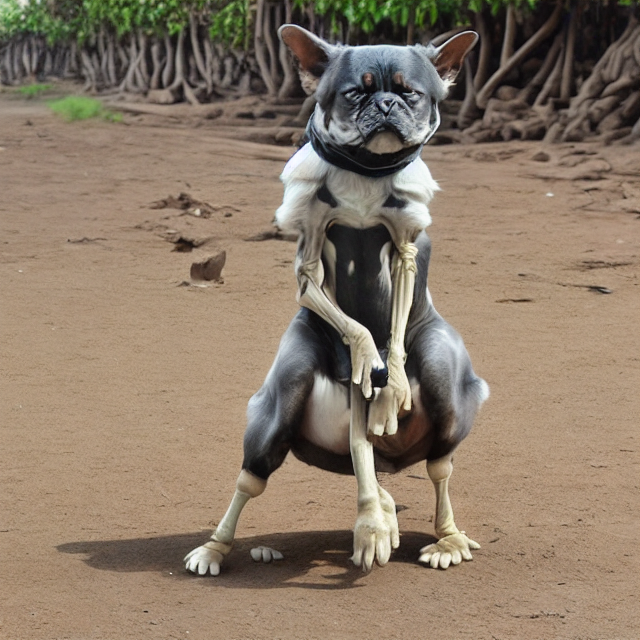

  0%|          | 0/6 [00:00<?, ?it/s]

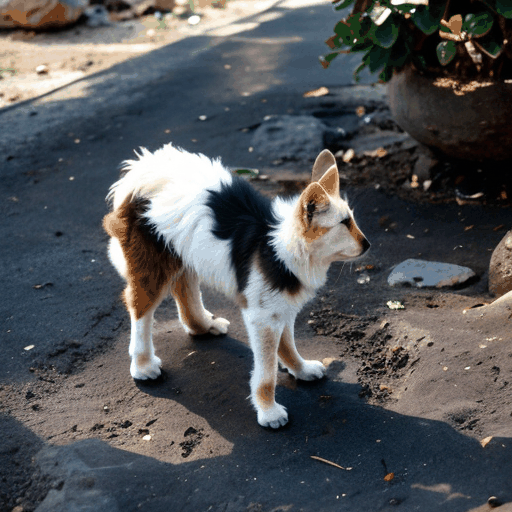

In [35]:

prompt = OUTPUT_TEXT

img = pipa(prompt).images[0]

display(img)

output = pipe(
    prompt=OUTPUT_TEXT,

negative_prompt = (
   "bad pose, awkward pose, unnatural posture, broken posture, "
"broken fingers, malformed fingers, extra fingers, missing fingers, "
"deformed hands, deformed feet, deformed legs, deformed arms, "
"long limbs, short limbs, twisted limbs, unnatural joints, "
"facial asymmetry, distorted mouth, distorted teeth, distorted nose, "
"distorted ears, deformed eyes, uneven eyes, blinking artifacts, "
"face melting, face warping, face morphing, identity drift, "
"skin flickering, hair flickering, hair changing, "
"clothing deformation, clothing flickering, clothing morphing, "
"accessory deformation, jewelry deformation"
),
    num_frames=16,
    guidance_scale=2.0,
    num_inference_steps=6,
    generator=torch.Generator(device="cpu").manual_seed(0),
)
frames = output.frames[0]

export_to_gif(frames, "animatelcm.gif")

from IPython.display import display
from IPython.display import Image as IPImage

display(IPImage(filename="animatelcm.gif"))